# Model Selection

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Clustering with Standard Scaler](#2-clustering-with-standard-scaler)
   - 2.1 K-Means
   - 2.2 Mean Shift
   - 2.3 Hierarchical Clustering
   - 2.4 DBSCAN
   - 2.5 SOM (Self-Organizing Map)
3. [Clustering with Robust Scaler](#3-clustering-with-robust-scaler)
   - 3.1 K-Means
   - 3.2 Mean Shift
   - 3.3 Hierarchical Clustering
   - 3.4 DBSCAN
   - 3.5 SOM (Self-Organizing Map)
4. [Clustering with MinMax Scaler](#4-clustering-with-minmax-scaler)
   - 4.1 K-Means
   - 4.2 Mean Shift
   - 4.3 Hierarchical Clustering
   - 4.4 DBSCAN
   - 4.5 SOM (Self-Organizing Map)
5. [Model Comparison](#5-model-comparison)
   - 5.1 Silhouette Comparison

# 1. Setup & Data Loading

In [2]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Import all clustering algorithms and helper functions from Clustering.py
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan,_initialize_som_weights, _find_bmu, 
    _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, plot_umap, plot_tsne
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

/Users/joanaanmartins/opt/anaconda3/envs/ds_limpo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('customer_info_engineered.csv')

In [4]:
df=df[['loyalty_product_type', 'lifetime_spend_vegetables_prop', 'lifetime_spend_meat_prop', 'lifetime_spend_hygiene_prop', 'lifetime_spend_videogames_prop', 'lifetime_spend_petfood_prop']]

df


,loyalty_product_type,lifetime_spend_vegetables_prop,lifetime_spend_meat_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop
0,98.359788,0.020065,0.001506,0.029693,0.013771,0.020656
1,155.638462,0.099442,0.002125,0.092918,0.016458,0.032867
2,191.962963,0.035694,0.081356,0.032607,0.006496,0.014277
3,162.521739,0.005618,0.065008,0.032437,0.110754,0.012306
4,4299.500000,0.014730,0.041400,0.011513,0.048765,0.017095
...,...,...,...,...,...,...
33033,122.962963,0.009538,0.051205,0.003112,0.080221,0.018373
33034,304.329897,0.009858,0.044817,0.007453,0.071308,0.007690
33035,68.412621,0.113532,0.021784,0.121975,0.006315,0.018307
33036,35.807792,0.043232,0.000000,0.029740,0.000000,0.016321


In [5]:
# Preprocess and scale the dataset using Standard, Robust, and MinMax scalers
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

In [6]:
# Run baseline profile analysis on the unscaled customer dataset
df_cluster_anaylsis = cluster_analysis(df)

# 2. Clustering with Standard Scaler

## 2.1 K-Means

k=2 | Inertia: 157627.40 | Silhouette: 0.3828
k=3 | Inertia: 133409.13 | Silhouette: 0.3680
k=4 | Inertia: 112288.45 | Silhouette: 0.3933
k=5 | Inertia: 93727.65 | Silhouette: 0.3952
k=6 | Inertia: 85104.30 | Silhouette: 0.2745
k=7 | Inertia: 77366.09 | Silhouette: 0.2853
k=8 | Inertia: 72714.25 | Silhouette: 0.2859
k=9 | Inertia: 69062.14 | Silhouette: 0.2869
k=10 | Inertia: 64521.93 | Silhouette: 0.2430


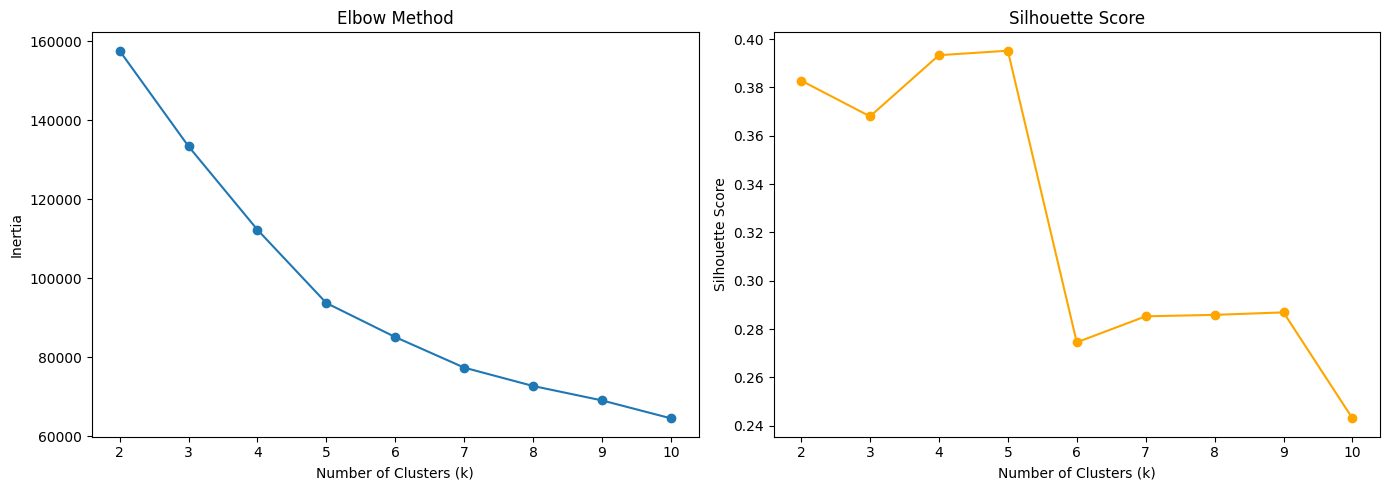

In [8]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_st)

In [9]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_st = fit_kmeans(df_processed_st, 5)
print(kmeans_profile_st)

Silhouette Score: 0.3952
Cluster sizes:
0     3041
1    20740
2     3288
3     5871
4       98
Name: count, dtype: int64
                                cluster_0  cluster_1  cluster_2  cluster_3  \
loyalty_product_type            -0.113364  -0.033995   0.054624  -0.083507   
lifetime_spend_vegetables_prop   0.191069  -0.387378  -0.567528   1.588859   
lifetime_spend_meat_prop         1.989615  -0.064126   0.221247  -0.925135   
lifetime_spend_hygiene_prop      0.600519  -0.336370  -0.669226   1.258055   
lifetime_spend_videogames_prop   0.154994  -0.342388   2.466462  -0.258333   
lifetime_spend_petfood_prop      1.699330  -0.319584  -0.238515   0.383516   

                                cluster_4  
loyalty_product_type            13.882359  
lifetime_spend_vegetables_prop  -0.091581  
lifetime_spend_meat_prop        -0.167860  
lifetime_spend_hygiene_prop     -0.362243  
lifetime_spend_videogames_prop   0.374883  
lifetime_spend_petfood_prop     -0.070124  


In [10]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_st = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans_st = kmeans_opt_st.fit_predict(df_processed_st)

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


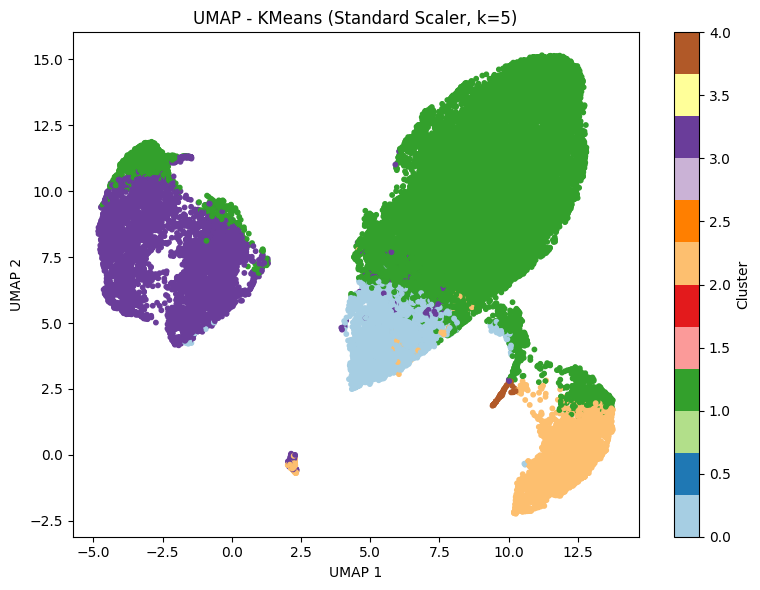

array([[ 6.826425  , 12.11961   ],
       [-0.16317506,  6.328582  ],
       [ 8.658224  ,  5.712434  ],
       ...,
       [-1.2305567 ,  6.663154  ],
       [ 7.012305  , 12.821206  ],
       [ 6.2764    ,  4.6603255 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_kmeans_st, title="UMAP - KMeans (Standard Scaler, k=5)")

## 2.2 Mean Shift

In [11]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_st = MeanShift(bin_seeding=True)
labels_ms_st = mean_shift_st.fit_predict(df_processed_st)
print("Standard Scaler MeanShift cluster count:", len(np.unique(labels_ms_st)))
if len(np.unique(labels_ms_st)) > 1:
    print(f"Standard Scaler MeanShift silhouette: {silhouette_score(df_processed_st, labels_ms_st):.4f}")
else:
    print("Standard Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_st).value_counts().sort_index())

Standard Scaler MeanShift cluster count: 74
Standard Scaler MeanShift silhouette: 0.3720
0     30772
1        28
2        11
3       107
4        82
      ...  
69        1
70        1
71        1
72        7
73        1
Name: count, Length: 74, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


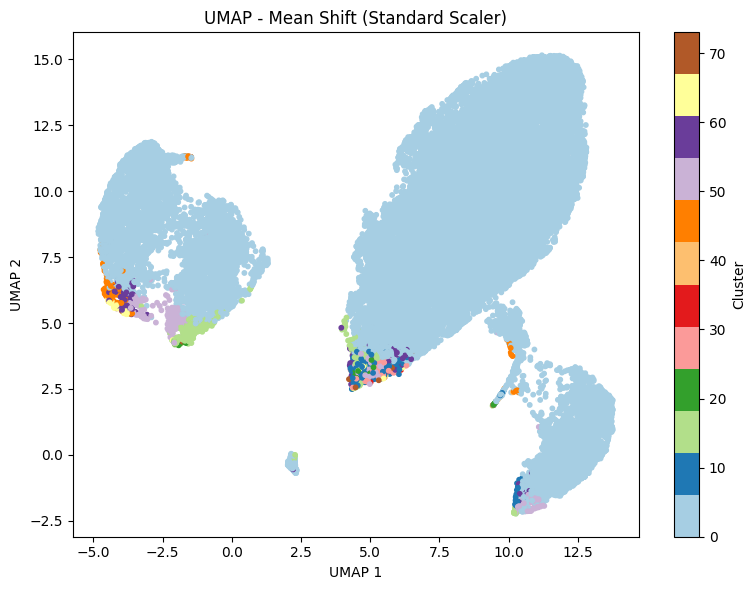

array([[ 6.826425  , 12.11961   ],
       [-0.16317506,  6.328582  ],
       [ 8.658224  ,  5.712434  ],
       ...,
       [-1.2305567 ,  6.663154  ],
       [ 7.012305  , 12.821206  ],
       [ 6.2764    ,  4.6603255 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_ms_st, title="UMAP - Mean Shift (Standard Scaler)")

## 2.3 Hierarchical Clustering

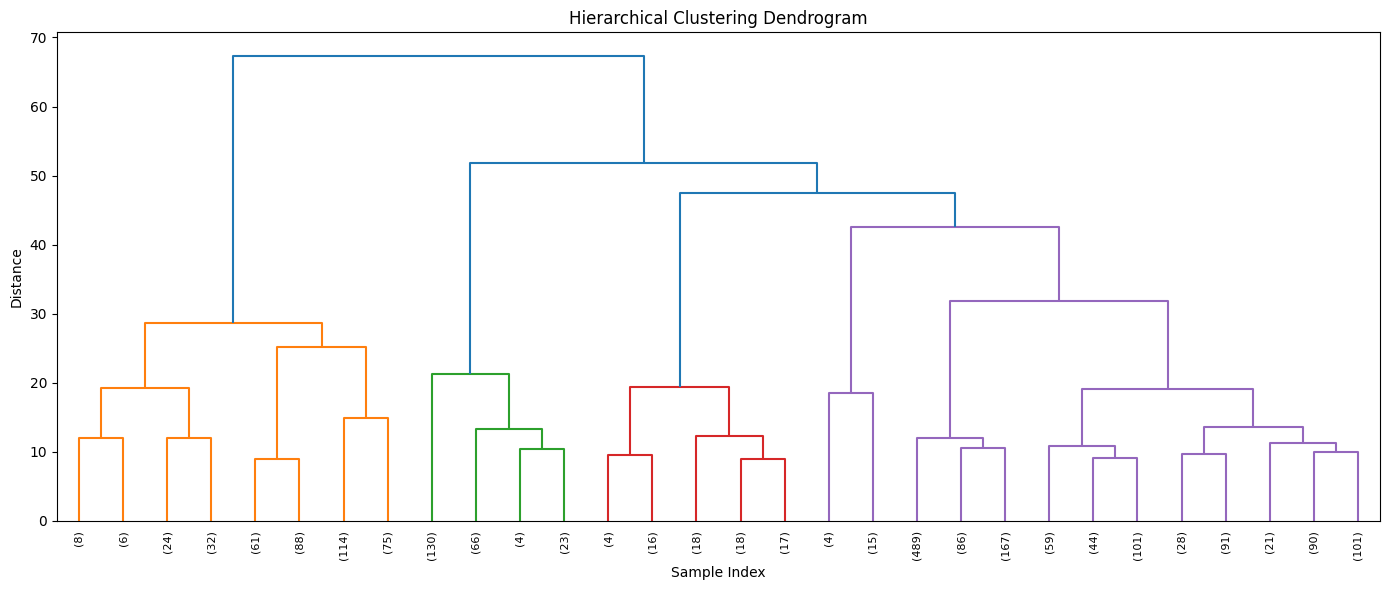

Silhouette Score: 0.3213
Cluster sizes:
0     6893
1      103
2     5291
3     2447
4    18304
Name: count, dtype: int64


In [12]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_st, labels_hierarchical_st, cluster_profile_hierarchical_st = fit_hierarchical(df_processed_st, 5, method='ward')

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


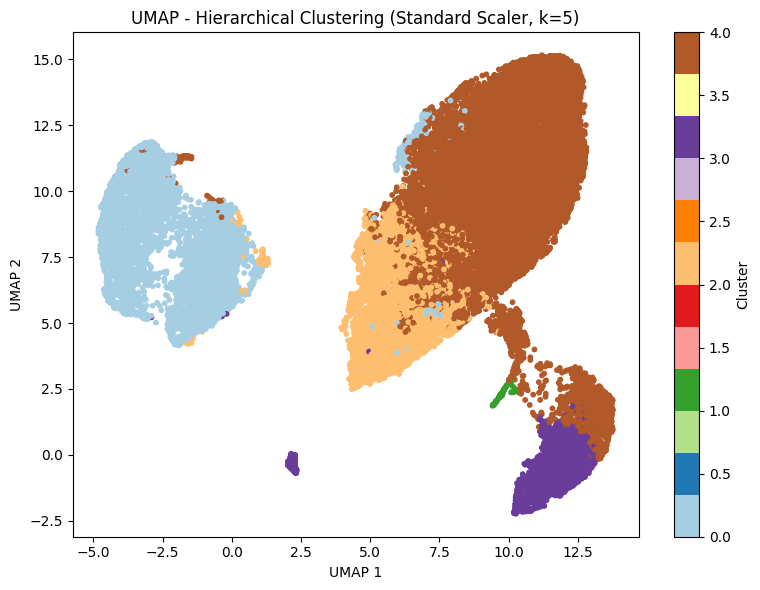

array([[ 6.826425  , 12.11961   ],
       [-0.16317506,  6.328582  ],
       [ 8.658224  ,  5.712434  ],
       ...,
       [-1.2305567 ,  6.663154  ],
       [ 7.012305  , 12.821206  ],
       [ 6.2764    ,  4.6603255 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_hierarchical_st, title="UMAP - Hierarchical Clustering (Standard Scaler, k=5)")

## 2.4 DBSCAN

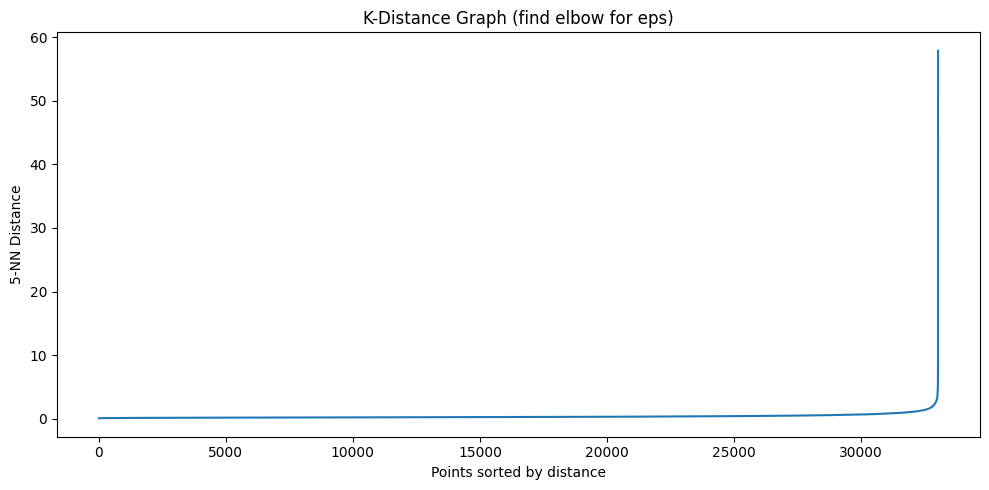

In [13]:
#Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_st, n_neighbors=5)

In [14]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 2.5, min_samples=5))

Number of clusters: 2
Noise points: 47 (0.14%)
Silhouette Score (excluding noise): 0.8675
Cluster sizes:
-1       47
 0    32980
 1       11
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0]))


Number of clusters: 1
Noise points: 20 (0.06%)
Cluster sizes:
-1       20
 0    33018
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


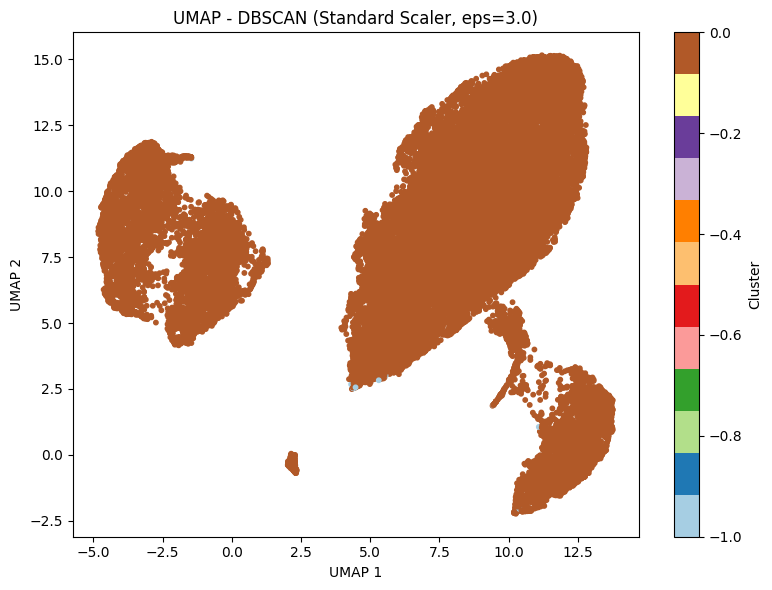

array([[ 6.826425  , 12.11961   ],
       [-0.16317506,  6.328582  ],
       [ 8.658224  ,  5.712434  ],
       ...,
       [-1.2305567 ,  6.663154  ],
       [ 7.012305  , 12.821206  ],
       [ 6.2764    ,  4.6603255 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_st, labels_dbscan_st = fit_dbscan(df_processed_st, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_dbscan_st, title="UMAP - DBSCAN (Standard Scaler, eps=3.0)")

In [15]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 10 (0.03%)
Cluster sizes:
-1       10
 0    33028
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0]))


## 2.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_st = fit_som(df_processed_st, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_st = get_som_cluster_labels(som_result_st['weights'], n_clusters=5, random_state=42)
print(neuron_labels_st)

[[0 0 0 0 1 2 2 2 2 2]
 [0 0 0 1 1 1 2 2 2 2]
 [0 0 0 1 1 1 1 2 2 2]
 [0 0 1 1 1 1 1 1 2 2]
 [1 1 1 1 1 1 1 1 1 2]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [3 3 3 1 1 1 1 1 1 1]
 [3 3 3 3 1 1 1 1 1 4]
 [3 3 3 3 1 1 1 1 4 4]]


In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_st, neuron_labels_st = assign_som_clusters(som_result_st['weights'], df_processed_st, n_clusters=5, random_state=42)#
print((labels_som_st, neuron_labels_st))

(array([1, 2, 1, ..., 2, 1, 0], shape=(33038,), dtype=int32), array([[0, 0, 0, 0, 1, 2, 2, 2, 2, 2],
       [0, 0, 0, 1, 1, 1, 2, 2, 2, 2],
       [0, 0, 0, 1, 1, 1, 1, 2, 2, 2],
       [0, 0, 1, 1, 1, 1, 1, 1, 2, 2],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 2],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [3, 3, 3, 1, 1, 1, 1, 1, 1, 1],
       [3, 3, 3, 3, 1, 1, 1, 1, 1, 4],
       [3, 3, 3, 3, 1, 1, 1, 1, 4, 4]], dtype=int32))


## 2.6 T-SNE

A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...
--- A gerar projeções t-SNE para comparação de modelos ---


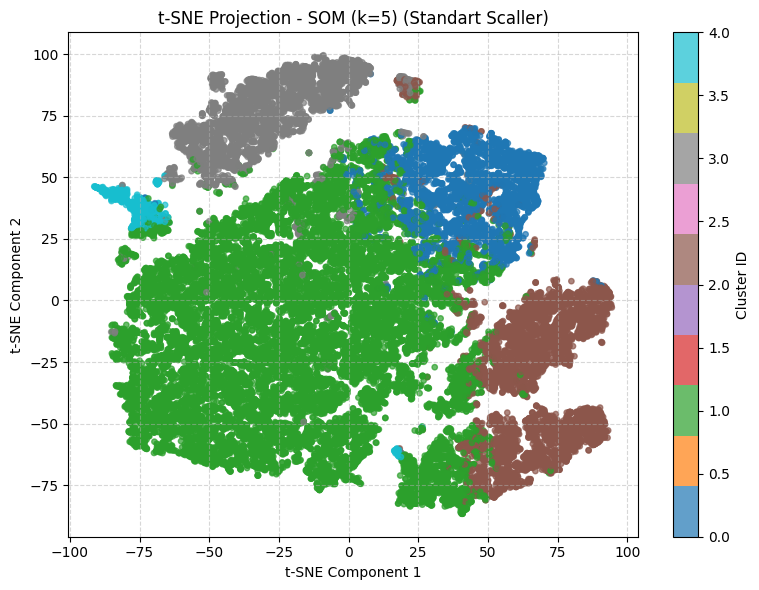

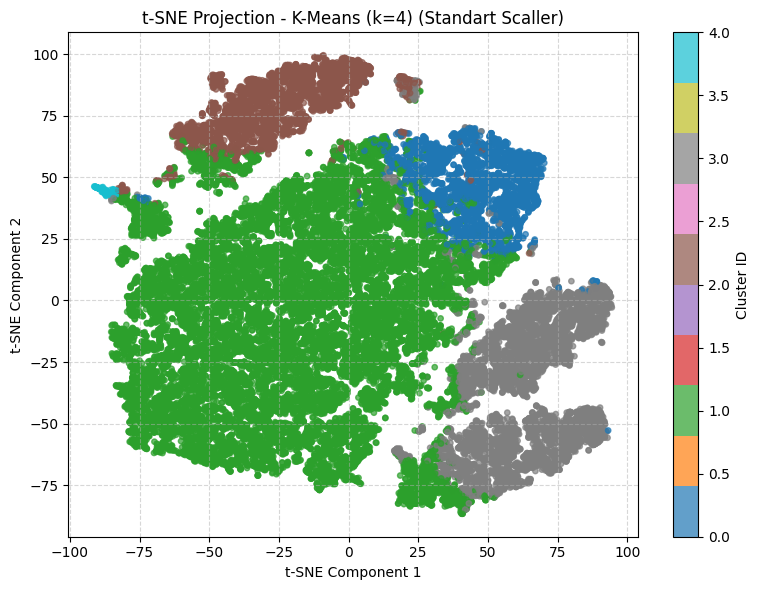

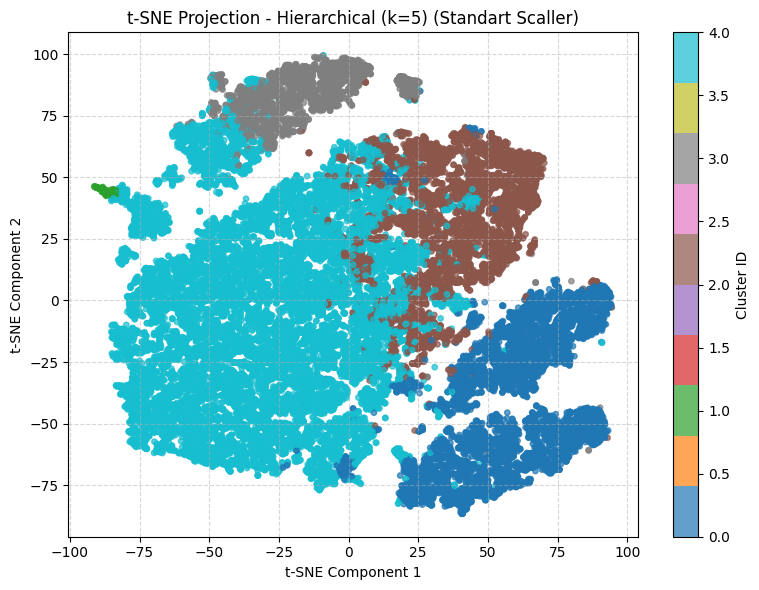

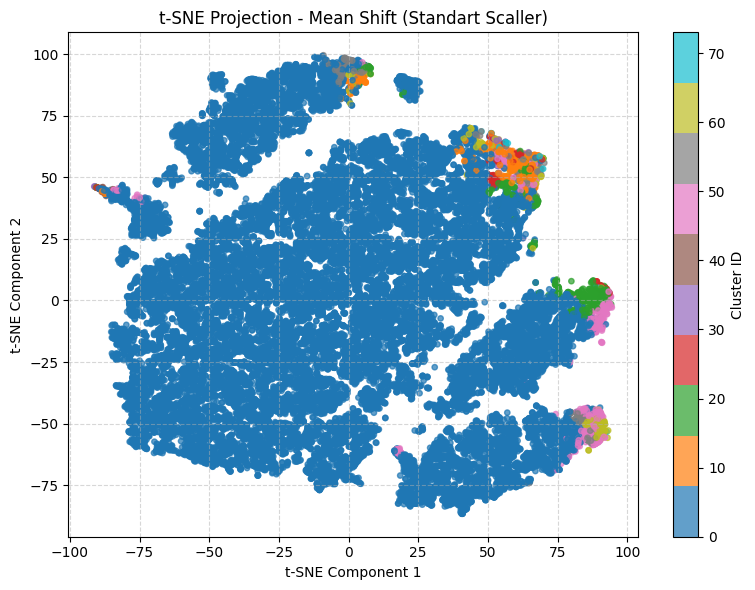

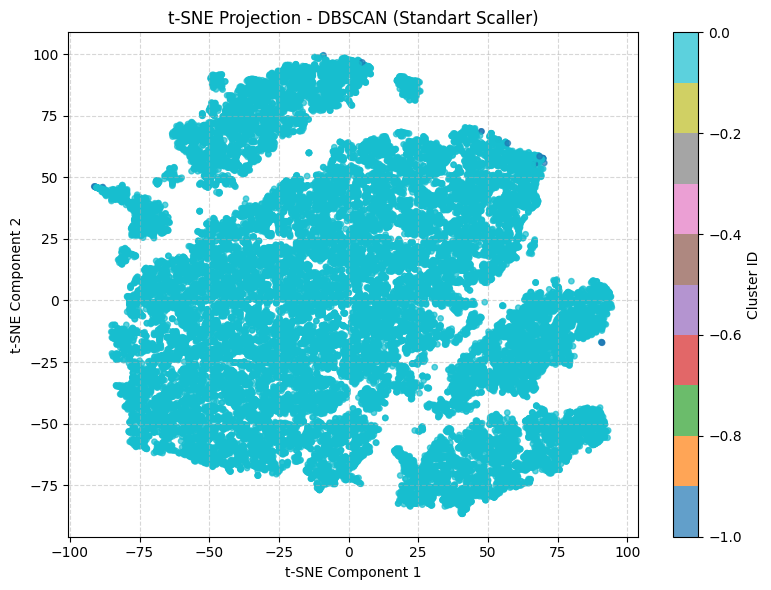

In [ ]:

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_st)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_st,
    'K-Means (k=4)': labels_kmeans_st,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_st, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_st,
    'DBSCAN': labels_dbscan_st                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (Standart Scaller)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    

# 3. Clustering with Robust Scaler

## 3.1 K-Means

In [ ]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_rb)

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower
OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower
OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable O

BLAS : Bad memory unallocation! :  768  0x9724e0000


In [ ]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_rb = fit_kmeans(df_processed_rb, 5)
print(kmeans_profile_rb)

Silhouette Score: 0.4933
Cluster sizes:
0     3720
1       72
2      386
3        1
4    28859
Name: count, dtype: int64
                                cluster_0   cluster_1  cluster_2   cluster_3  \
loyalty_product_type             0.889776  105.120910  26.911323  566.906183   
lifetime_spend_vegetables_prop  -0.040291    0.309690   0.251733   -0.258552   
lifetime_spend_meat_prop         0.512394    0.011726   0.101105   -0.643893   
lifetime_spend_hygiene_prop     -0.232276   -0.071924  -0.029339   -0.497993   
lifetime_spend_videogames_prop   5.053877    1.192197   1.006575   -0.152985   
lifetime_spend_petfood_prop      0.245463    0.177296   0.088312   -0.878557   

                                cluster_4  
loyalty_product_type             0.396607  
lifetime_spend_vegetables_prop   0.458564  
lifetime_spend_meat_prop         0.070182  
lifetime_spend_hygiene_prop      0.374908  
lifetime_spend_videogames_prop   0.056755  
lifetime_spend_petfood_prop      0.209727  


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


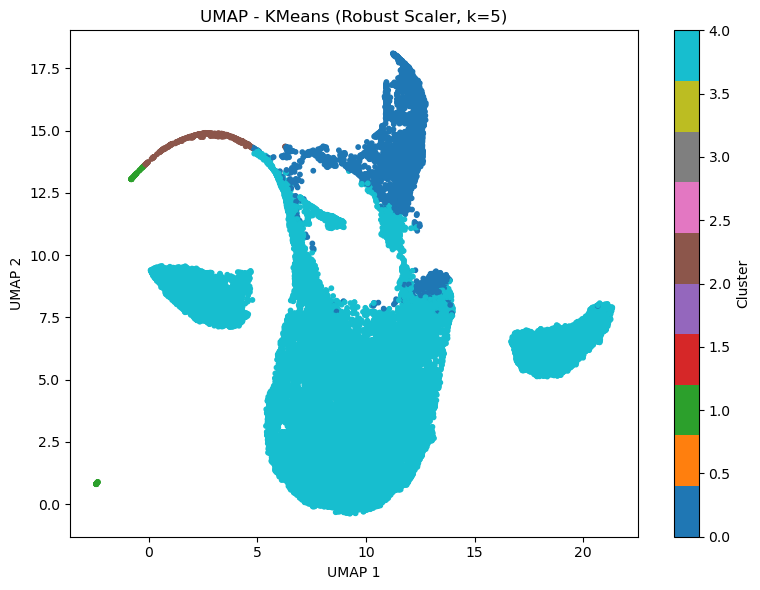

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_rb = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans_rb = kmeans_opt_rb.fit_predict(df_processed_rb)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_kmeans_rb, title="UMAP - KMeans (Robust Scaler, k=5)")

## 3.2 Mean Shift

In [ ]:

# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_rb = MeanShift(bin_seeding=True)
labels_ms_rb = mean_shift_rb.fit_predict(df_processed_rb)
print("Robust Scaler MeanShift cluster count:", len(np.unique(labels_ms_rb)))
if len(np.unique(labels_ms_rb)) > 1:
    print(f"Robust Scaler MeanShift silhouette: {silhouette_score(df_processed_rb, labels_ms_rb):.4f}")
else:
    print("Robust Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_rb).value_counts().sort_index())


Robust Scaler MeanShift cluster count: 72
Robust Scaler MeanShift silhouette: 0.4437
0     30695
1        81
2        31
3        25
4        21
      ...  
67      123
68        1
69       58
70        1
71        9
Name: count, Length: 72, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


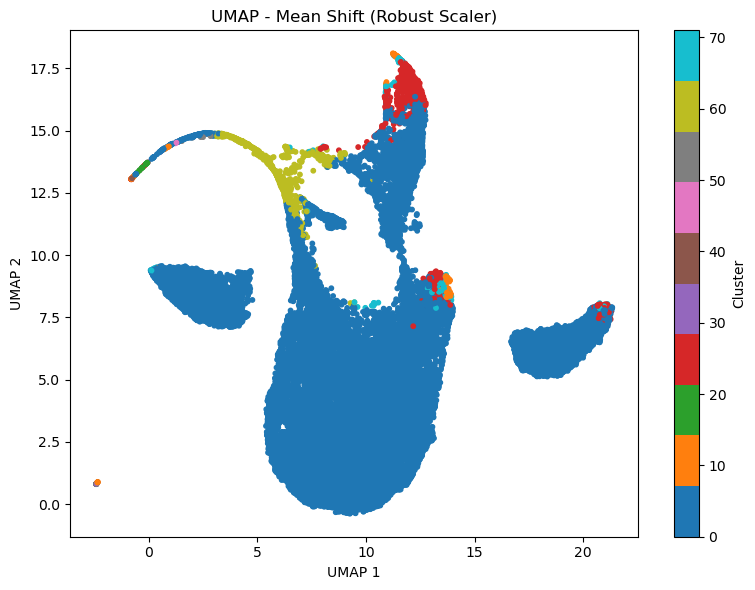

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_ms_rb, title="UMAP - Mean Shift (Robust Scaler)")

## 3.3 Hierarchical Clustering

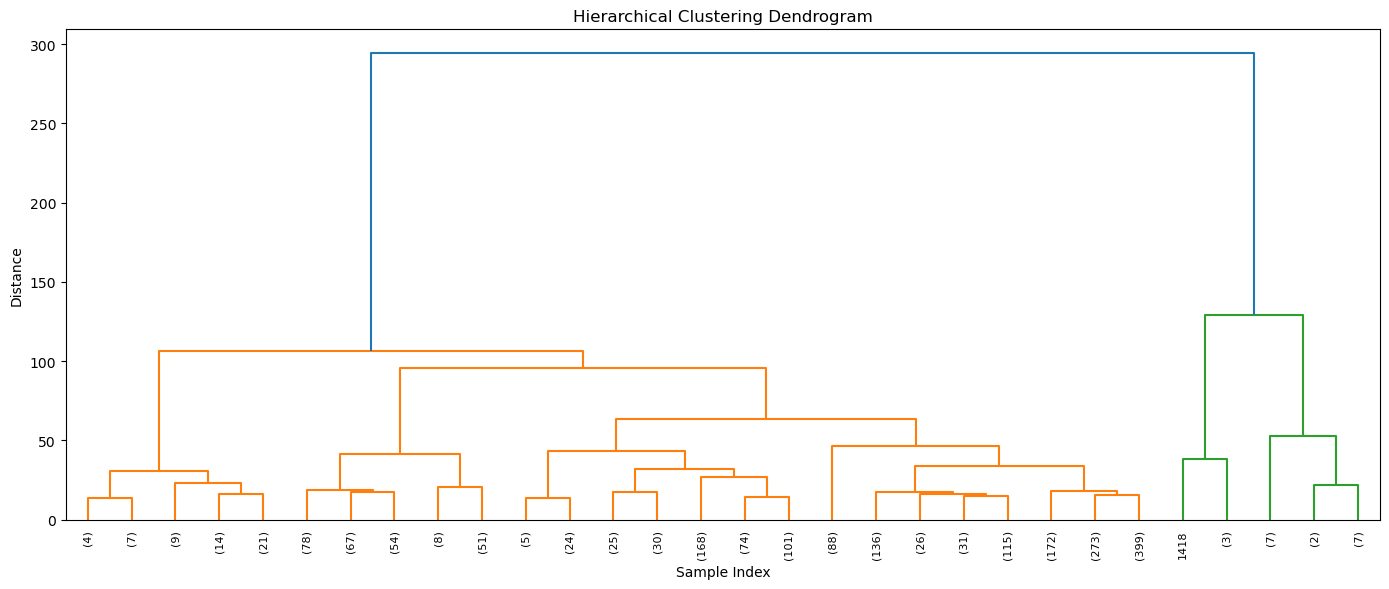

Silhouette Score: 0.5015
Cluster sizes:
0     4288
1       71
2      221
3        1
4    28457
Name: count, dtype: int64


ValueError: too many values to unpack (expected 2)

In [ ]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_rb, labels_hierarchical_rb = fit_hierarchical(df_processed_rb, 5, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


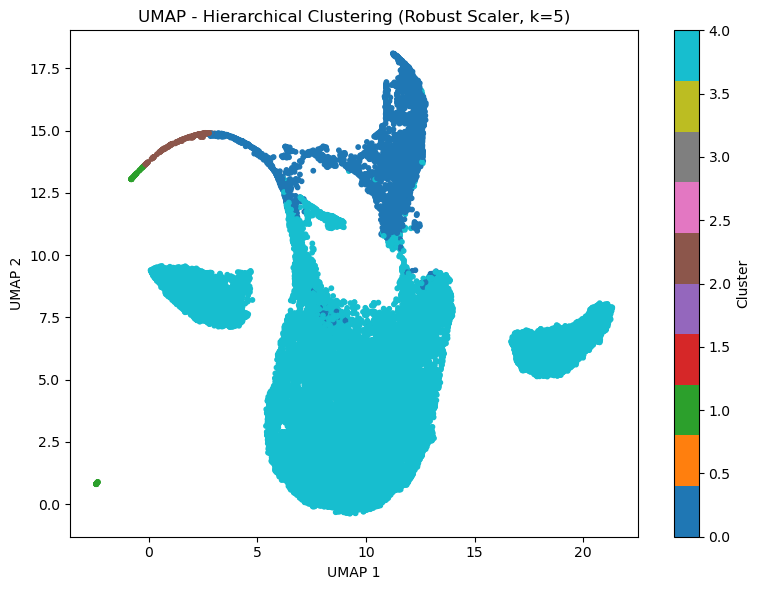

array([[ 9.7369   ,  3.0249918],
       [ 2.6205177,  8.964956 ],
       [10.663879 ,  5.7185006],
       ...,
       [ 2.0087202,  8.10538  ],
       [ 8.891738 ,  2.510032 ],
       [13.452457 ,  6.89132  ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_hierarchical_rb, title="UMAP - Hierarchical Clustering (Robust Scaler, k=5)")

## 3.4 DBSCAN

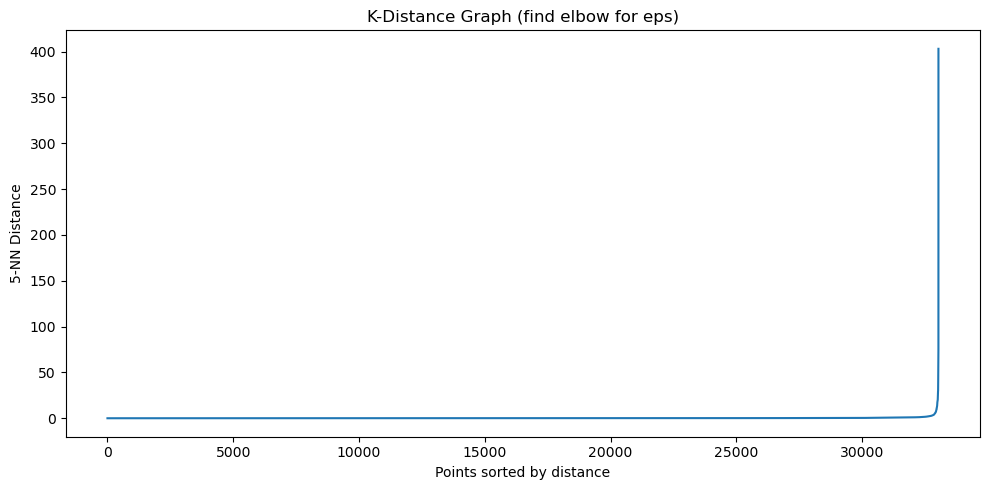

In [ ]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_rb, n_neighbors=5)

In [ ]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 2.5, min_samples=5))

Number of clusters: 7
Noise points: 257 (0.78%)
Silhouette Score (excluding noise): 0.8895
Cluster sizes:
-1      257
 0    32739
 1        8
 2       13
 3        5
 4        5
 5        5
 6        6
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


Number of clusters: 4
Noise points: 211 (0.64%)
Silhouette Score (excluding noise): 0.8905
Cluster sizes:
-1      211
 0    32810
 1        7
 2        5
 3        5
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


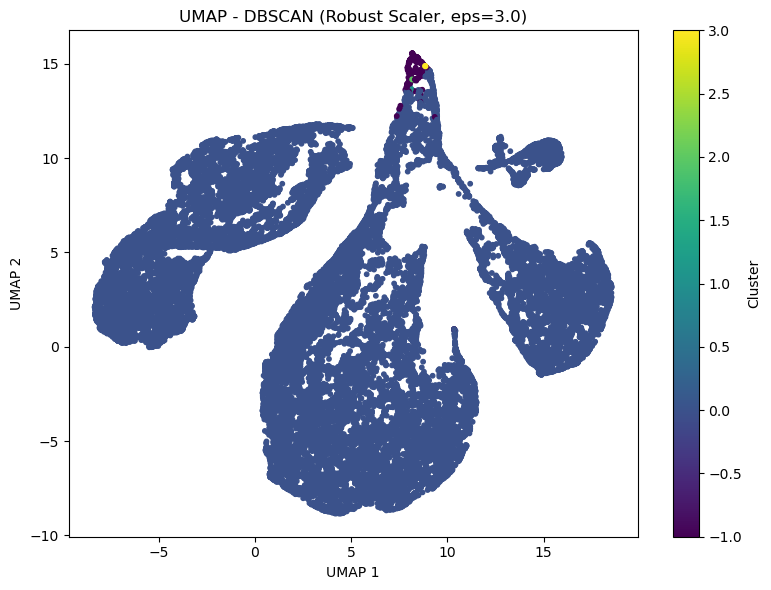

array([[ 1.3558738, -6.523966 ],
       [-1.0625837,  7.88735  ],
       [ 2.3241198, -2.2847686],
       ...,
       [-4.5307264,  3.693696 ],
       [10.034536 , -6.7146597],
       [ 1.0412196, -3.262857 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_rb, labels_dbscan_rb = fit_dbscan(df_processed_rb, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_dbscan_rb, title="UMAP - DBSCAN (Robust Scaler, eps=3.0)")

In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 3.5, min_samples=5))

Number of clusters: 4
Noise points: 179 (0.54%)
Silhouette Score (excluding noise): 0.9094
Cluster sizes:
-1      179
 0    32840
 1        6
 2        8
 3        5
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## 3.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_rb = fit_som(df_processed_rb, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_rb = get_som_cluster_labels(som_result_rb['weights'], n_clusters=5, random_state=42)
print(neuron_labels_rb)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_rb, neuron_labels_rb = assign_som_clusters(som_result_rb['weights'], df_processed_rb, n_clusters=5, random_state=42)
print((labels_som_rb, neuron_labels_rb))

## 3.6 T-SNE

In [ ]:

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_rb)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_rb,
    'K-Means (k=4)': labels_kmeans_rb,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_rb, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_rb,
    'DBSCAN': labels_dbscan_rb                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (Robust Scaler)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


'\nimport matplotlib.pyplot as plt\nfrom sklearn.manifold import TSNE\n\n# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset\n# (Isto é o que demora tempo, por isso fazemos fora do loop)\ntsne = TSNE(n_components=2, perplexity=50, random_state=42, init=\'pca\', max_iter=1000)\n\nprint("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")\nX_tsne = tsne.fit_transform(df_processed_rb)\n\n\n# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos\n# Certifica-te de que já correstes as células que criam estas variáveis de labels!\nlabels_todos_modelos = {\n    \'SOM (k=5)\': labels_som_rb,\n    \'K-Means (k=4)\': labels_kmeans_rb,          # Descomenta se tiveres esta variável\n    \'Hierarchical (k=5)\': labels_hierarchical_rb, # Descomenta se tiveres esta variável\n    \'Mean Shift\': labels_ms_rb,\n    \'DBSCAN\': labels_dbscan_rb                    # Descomenta se tiveres esta variável\n}\n\n\n# 3. O LOO

# 4. Clustering with MinMax Scaler

## 4.1 K-Means

k=2 | Inertia: 927.81 | Silhouette: 0.4532
k=3 | Inertia: 747.87 | Silhouette: 0.4178
k=4 | Inertia: 638.56 | Silhouette: 0.4184
k=5 | Inertia: 556.55 | Silhouette: 0.4045
k=6 | Inertia: 495.59 | Silhouette: 0.4168
k=7 | Inertia: 450.17 | Silhouette: 0.2966
k=8 | Inertia: 418.79 | Silhouette: 0.2980
k=9 | Inertia: 391.89 | Silhouette: 0.3006
k=10 | Inertia: 371.21 | Silhouette: 0.2911


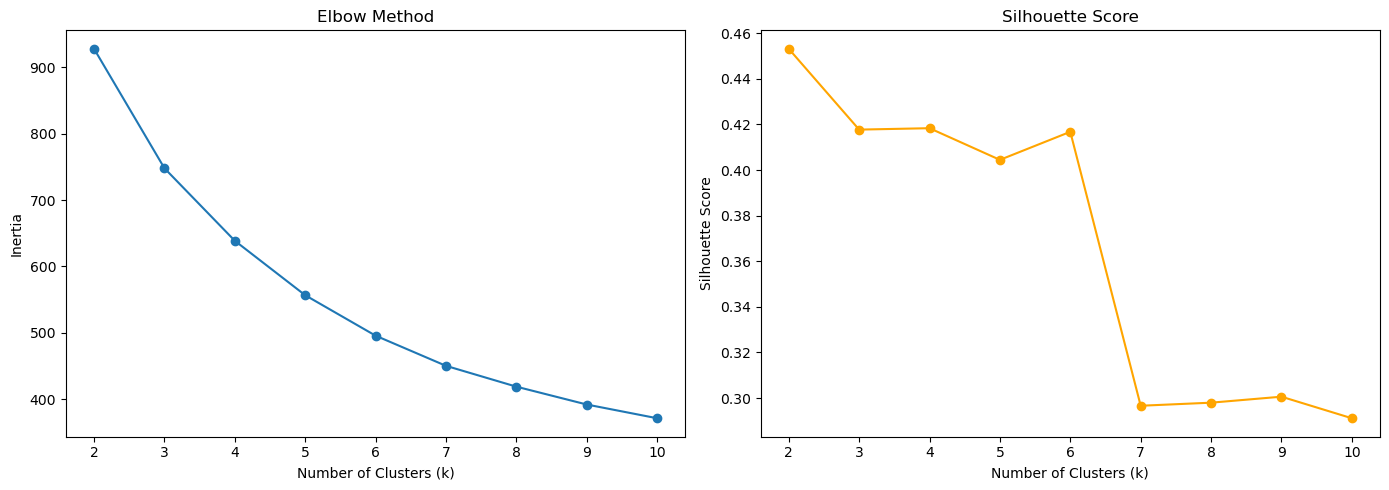

In [ ]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_mm)

In [ ]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_mm = fit_kmeans(df_processed_mm, 5)
print(kmeans_profile_mm)

Silhouette Score: 0.4045
Cluster sizes:
0     2900
1     5237
2     3287
3    19618
4     1996
Name: count, dtype: int64
                                cluster_0  cluster_1  cluster_2  cluster_3  \
average_value_per_product        0.002133   0.003695   0.005491   0.003632   
lifetime_spend_vegetables_prop   0.121062   0.239408   0.030756   0.048486   
lifetime_spend_meat_prop         0.221005   0.021445   0.101458   0.083523   
lifetime_spend_hygiene_prop      0.191817   0.160454   0.039805   0.074797   
lifetime_spend_videogames_prop   0.084275   0.039066   0.285167   0.038269   
lifetime_spend_petfood_prop      0.185353   0.080865   0.068332   0.064912   

                                cluster_4  
average_value_per_product        0.002036  
lifetime_spend_vegetables_prop   0.396014  
lifetime_spend_meat_prop         0.033234  
lifetime_spend_hygiene_prop      0.345752  
lifetime_spend_videogames_prop   0.068670  
lifetime_spend_petfood_prop      0.154890  


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


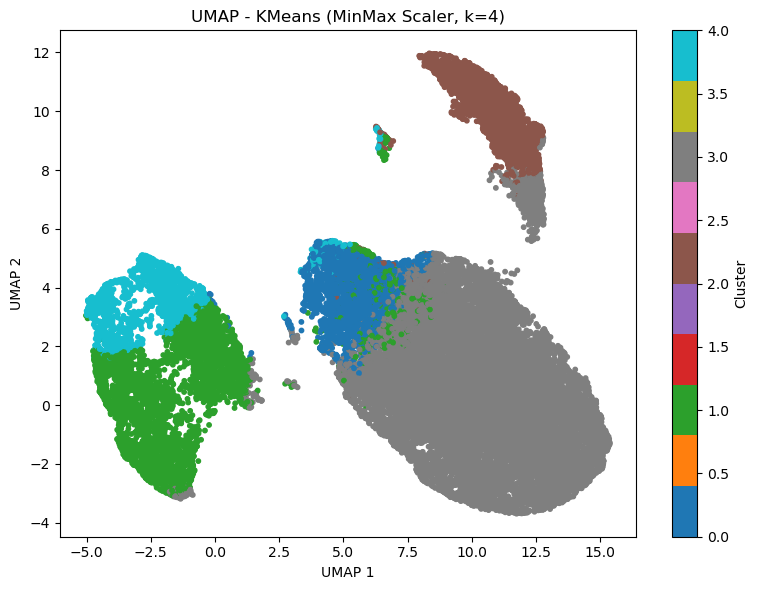

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [ ]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(df_processed_mm)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_kmeans_mm, title="UMAP - KMeans (MinMax Scaler, k=4)")

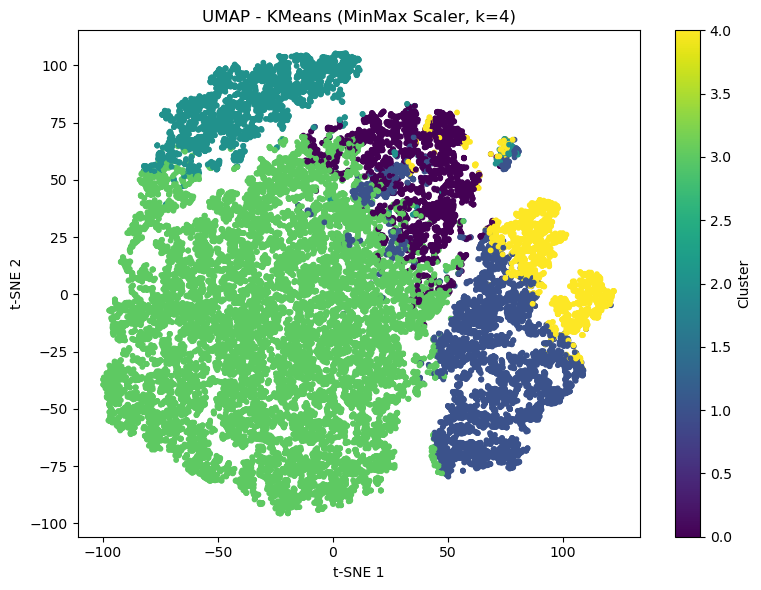

array([[ -0.3213858, -52.14148  ],
       [ 82.75395  ,   4.9443784],
       [ 14.880265 ,  30.168186 ],
       ...,
       [ 81.64467  ,  12.910972 ],
       [  6.0372896, -57.16223  ],
       [ 41.915962 ,  48.94255  ]], shape=(33038, 2), dtype=float32)

In [ ]:
plot_tsne(df_processed_mm, labels_kmeans_mm, title="UMAP - KMeans (MinMax Scaler, k=4)")

## 4.2 Mean Shift

In [ ]:

# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_mm = MeanShift(bin_seeding=True)
labels_ms_mm = mean_shift_mm.fit_predict(df_processed_mm)
print("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))
if len(np.unique(labels_ms_mm)) > 1:
    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_processed_mm, labels_ms_mm):.4f}")
else:
    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_mm).value_counts().sort_index())


'\n# Fit Mean Shift clustering to automatically determine the number of clusters\nmean_shift_mm = MeanShift(bin_seeding=True)\nlabels_ms_mm = mean_shift_mm.fit_predict(df_processed_mm)\nprint("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))\nif len(np.unique(labels_ms_mm)) > 1:\n    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_processed_mm, labels_ms_mm):.4f}")\nelse:\n    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")\nprint(pd.Series(labels_ms_mm).value_counts().sort_index())\n'

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_ms_mm, title="UMAP - Mean Shift (MinMax Scaler)")

## 4.3 Hierarchical Clustering

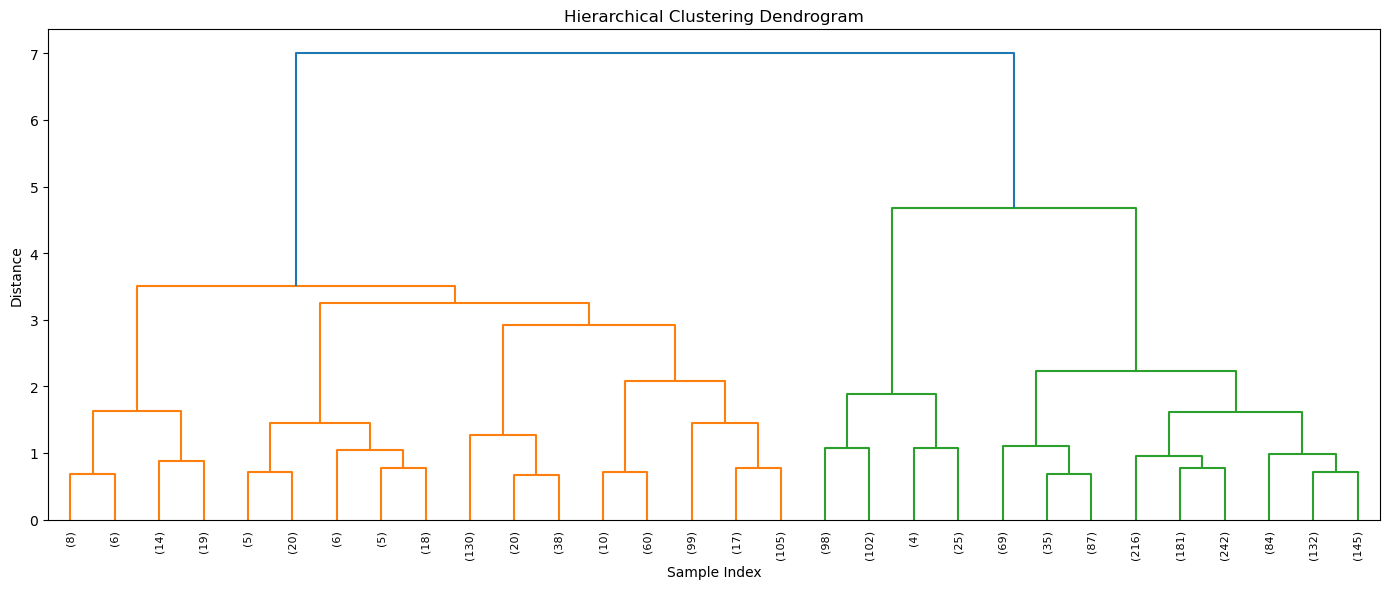

Silhouette Score: 0.3788
Cluster sizes:
0    21008
1     3111
2     3911
3     1467
4      993
5     2548
Name: count, dtype: int64


In [ ]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm = fit_hierarchical(df_processed_mm, 6, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


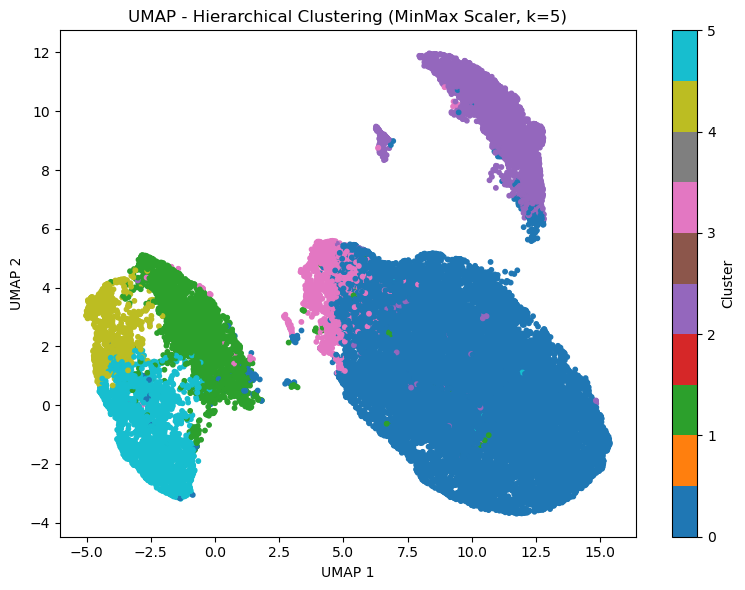

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=5)")

## 4.4 DBSCAN

In [ ]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_mm, n_neighbors=5)

In [ ]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 2.5, min_samples=5))

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_mm, labels_dbscan_mm = fit_dbscan(df_processed_mm, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_dbscan_mm, title="UMAP - DBSCAN (MinMax Scaler, eps=3.0)")

In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 3.5, min_samples=5))

## 4.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_mm = fit_som(df_processed_mm, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_mm = get_som_cluster_labels(som_result_mm['weights'], n_clusters=5, random_state=42)
print(neuron_labels_mm)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_mm, neuron_labels_mm = assign_som_clusters(som_result_mm['weights'], df_processed_mm, n_clusters=5, random_state=42)
print((labels_som_mm, neuron_labels_mm))

## 4.6 T-SNE

In [ ]:

mport matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_mm)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_mm,
    'K-Means (k=4)': labels_kmeans_mm,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_mm, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_mm,
    'DBSCAN': labels_dbscan_mm                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (MinMax Scaler)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


'\nmport matplotlib.pyplot as plt\nfrom sklearn.manifold import TSNE\n\n# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset\n# (Isto é o que demora tempo, por isso fazemos fora do loop)\ntsne = TSNE(n_components=2, perplexity=50, random_state=42, init=\'pca\', max_iter=1000)\n\nprint("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")\nX_tsne = tsne.fit_transform(df_processed_mm)\n\n\n# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos\n# Certifica-te de que já correstes as células que criam estas variáveis de labels!\nlabels_todos_modelos = {\n    \'SOM (k=5)\': labels_som_mm,\n    \'K-Means (k=4)\': labels_kmeans_mm,          # Descomenta se tiveres esta variável\n    \'Hierarchical (k=5)\': labels_hierarchical_mm, # Descomenta se tiveres esta variável\n    \'Mean Shift\': labels_ms_mm,\n    \'DBSCAN\': labels_dbscan_mm                    # Descomenta se tiveres esta variável\n}\n\n\n# 3. O LOOP